In [1]:
import pandas as pd
import numpy as np

columns = [
    "OrderID",
    "CustomerID",
    "OrderDate",
    "ProductID",
    "UnitPrice",
    "Quantity",
    "Discount"
]

# Load both halves of the original CSV dataset
part1 = pd.read_csv(
    "task4_join_export_part1.csv",
    header=None,
    names=columns
)

part2 = pd.read_csv(
    "task4_join_export_part2.csv",
    header=None,
    names=columns
)

# Combine both parts
df = pd.concat([part1, part2], ignore_index=True)

# Convert OrderDate to datetime
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    format="mixed"
)

# Display dataset information
print("Part 1 shape:", part1.shape)
print("Part 2 shape:", part2.shape)
print("Combined shape:", df.shape)

print("\nDataFrame information:")
df.info()

Part 1 shape: (304642, 7)
Part 2 shape: (304642, 7)
Combined shape: (609284, 7)

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609284 entries, 0 to 609283
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   OrderID     609284 non-null  int64         
 1   CustomerID  609284 non-null  object        
 2   OrderDate   609284 non-null  datetime64[ns]
 3   ProductID   609284 non-null  int64         
 4   UnitPrice   609284 non-null  float64       
 5   Quantity    609284 non-null  int64         
 6   Discount    609284 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 32.5+ MB


In [2]:
# Task 1 :

print("===== DATASET INFORMATION =====")
df.info()

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe(include="all"))

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609284 entries, 0 to 609283
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   OrderID     609284 non-null  int64         
 1   CustomerID  609284 non-null  object        
 2   OrderDate   609284 non-null  datetime64[ns]
 3   ProductID   609284 non-null  int64         
 4   UnitPrice   609284 non-null  float64       
 5   Quantity    609284 non-null  int64         
 6   Discount    609284 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 32.5+ MB

===== DESCRIPTIVE STATISTICS =====
              OrderID CustomerID                      OrderDate  \
count   609284.000000     609284                         609284   
unique            NaN         93                            NaN   
top               NaN      BSBEV                            NaN   
freq              NaN       828

In [3]:
# Task 2 :

# a :
# Convert UnitPrice column to a NumPy array
unit_price_array = df["UnitPrice"].to_numpy()

# Apply a 10% price adjustment using vectorized NumPy arithmetic
adjusted_price_array = unit_price_array * 1.10

print("===== Task 2(a) — Vectorized NumPy Operation =====")
print("Original UnitPrice values:", unit_price_array[:10])
print("Adjusted UnitPrice values:", adjusted_price_array[:10])


# b :
# Select rows where UnitPrice >= 20 AND Quantity >= 30
filtered_array = df[
    (df["UnitPrice"] >= 20) &
    (df["Quantity"] >= 30)
]

print("\n===== Task 2(b) — Boolean-Indexed Filtering =====")
print("Number of rows matching both conditions:", len(filtered_array))

print("\nFirst 10 matching rows:")
print(
    filtered_array[
        ["OrderID", "ProductID", "UnitPrice", "Quantity", "Discount"]
    ].head(10)
)

===== Task 2(a) — Vectorized NumPy Operation =====
Original UnitPrice values: [14.   9.8 34.8 18.6 42.4  7.7 42.4 16.8 16.8 15.6]
Adjusted UnitPrice values: [15.4  10.78 38.28 20.46 46.64  8.47 46.64 18.48 18.48 17.16]

===== Task 2(b) — Boolean-Indexed Filtering =====
Number of rows matching both conditions: 126277

First 10 matching rows:
     OrderID  ProductID  UnitPrice  Quantity  Discount
4      10249         51       42.4        40      0.00
6      10250         51       42.4        35      0.15
11     10252         20       64.8        40      0.05
13     10252         60       27.2        40      0.00
23     10255         59       44.0        30      0.00
45     10263         30       20.7        60      0.25
49     10265         17       31.2        30      0.00
53     10267         59       44.0        70      0.15
93     10283         60       27.2        35      0.00
101    10285         53       26.2        36      0.20


In [4]:
# Task 3 :

unit_prices = df["UnitPrice"].to_numpy()
quantities = df["Quantity"].to_numpy()

print("===== Task 3 — NumPy Descriptive Statistics =====")

for column in ["UnitPrice", "Quantity"]:
    values = df[column].to_numpy()

    print(f"\n{column}")
    print("Mean:", np.mean(values))
    print("Median:", np.median(values))
    print("90th Percentile:", np.percentile(values, 90))
    print("Standard deviation:", np.std(values))
    print("Minimum:", np.min(values))
    print("Maximum:", np.max(values))

===== Task 3 — NumPy Descriptive Statistics =====

UnitPrice
Mean: 28.850354957622393
Median: 19.5
90th Percentile: 49.3
Standard deviation: 33.565420774120696
Minimum: 2.0
Maximum: 263.5

Quantity
Mean: 25.50307245882052
Median: 25.0
90th Percentile: 46.0
Standard deviation: 14.453925502162077
Minimum: 1
Maximum: 130


In [5]:
# Task 4 :
# Create TotalValue using Quantity × UnitPrice

df["TotalValue"] = df["Quantity"] * df["UnitPrice"]

print("===== Task 4 — Feature Engineering =====")
print("Created column: TotalValue = Quantity × UnitPrice")

print("\nFirst 10 rows:")
print(df[["OrderID", "ProductID", "UnitPrice", "Quantity", "TotalValue"]].head(10))

print("\nTotalValue statistics:")
print(df["TotalValue"].describe())

===== Task 4 — Feature Engineering =====
Created column: TotalValue = Quantity × UnitPrice

First 10 rows:
   OrderID  ProductID  UnitPrice  Quantity  TotalValue
0    10248         11       14.0        12       168.0
1    10248         42        9.8        10        98.0
2    10248         72       34.8         5       174.0
3    10249         14       18.6         9       167.4
4    10249         51       42.4        40      1696.0
5    10250         41        7.7        10        77.0
6    10250         51       42.4        35      1484.0
7    10250         65       16.8        15       252.0
8    10251         22       16.8         6       100.8
9    10251         57       15.6        15       234.0

TotalValue statistics:
count    609284.000000
mean        736.069660
std        1069.683989
min           2.500000
25%         216.000000
50%         462.000000
75%         864.800000
max       15810.000000
Name: TotalValue, dtype: float64


In [6]:
# Task 5 — Grouped Analysis

print("===== Task a — Pivot Table 1 =====")

# Pivot table showing total sales value by CustomerID
pivot_customer = df.pivot_table(
    index="CustomerID",
    values="TotalValue",
    aggfunc="sum"
).sort_values("TotalValue", ascending=False)

print(pivot_customer.head(10))


print("\n===== Task b — Pivot Table 2 =====")

# Pivot table showing average UnitPrice and Quantity by ProductID
pivot_product = df.pivot_table(
    index="ProductID",
    values=["UnitPrice", "Quantity"],
    aggfunc="mean"
).sort_values("UnitPrice", ascending=False)

print(pivot_product.head(10))

print("\n===== Task c — Multi-Aggregation GroupBy =====")

# Multiple aggregation functions across multiple columns
grouped_analysis = df.groupby("ProductID").agg({
    "TotalValue": ["sum", "mean"],
    "Quantity": ["sum", "mean"]
}).sort_values(
    ("TotalValue", "sum"),
    ascending=False
)

print(grouped_analysis.head(10))

===== Task a — Pivot Table 1 =====
            TotalValue
CustomerID            
BSBEV       6154115.34
HUNGC       5698023.67
RANCH       5559110.08
GOURL       5552597.90
ANATR       5534356.65
RICAR       5524990.91
FOLIG       5505502.85
LETSS       5462611.57
LILAS       5439186.80
PRINI       5437042.71

===== Task b — Pivot Table 2 =====
            Quantity   UnitPrice
ProductID                       
38         25.583049  263.446667
29         25.361285  123.758408
9          25.442510   96.997535
20         25.707838   80.989874
18         25.631686   62.490471
59         25.574668   54.973816
51         25.435123   52.987947
62         25.538559   49.282478
43         25.604642   45.989555
28         25.510620   45.584969

===== Task c — Multi-Aggregation GroupBy =====
            TotalValue              Quantity           
                   sum         mean      sum       mean
ProductID                                              
38         53274482.70  6739.340000   202

In [7]:
# Task 6 — Bucket Segmentation

print("===== Task 6 — Bucket Segmentation =====")

# Function to map TotalValue into labelled buckets
def value_bucket(value):
    if value < 300:
        return "Low Value"
    elif value < 1000:
        return "Medium Value"
    else:
        return "High Value"


# Apply the function across the DataFrame
df["ValueBucket"] = df["TotalValue"].apply(value_bucket)

# Display the new categorical column
print("\nFirst 10 rows with ValueBucket:")
print(
    df[
        ["OrderID", "ProductID", "Quantity", "UnitPrice",
         "TotalValue", "ValueBucket"]
    ].head(10)
)

# Show the number of observations in each bucket
print("\nValueBucket counts:")
print(df["ValueBucket"].value_counts())

===== Task 6 — Bucket Segmentation =====

First 10 rows with ValueBucket:
   OrderID  ProductID  Quantity  UnitPrice  TotalValue ValueBucket
0    10248         11        12       14.0       168.0   Low Value
1    10248         42        10        9.8        98.0   Low Value
2    10248         72         5       34.8       174.0   Low Value
3    10249         14         9       18.6       167.4   Low Value
4    10249         51        40       42.4      1696.0  High Value
5    10250         41        10        7.7        77.0   Low Value
6    10250         51        35       42.4      1484.0  High Value
7    10250         65        15       16.8       252.0   Low Value
8    10251         22         6       16.8       100.8   Low Value
9    10251         57        15       15.6       234.0   Low Value

ValueBucket counts:
ValueBucket
Medium Value    279707
Low Value       206873
High Value      122704
Name: count, dtype: int64


In [8]:
# ===== Task 7 — Correlation Analysis =====

numeric_columns = [
    "OrderID",
    "ProductID",
    "UnitPrice",
    "Quantity",
    "Discount",
    "TotalValue"
]

# Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

print("===== Task 7 — Correlation Analysis =====")
print("\nCorrelation matrix:")
print(correlation_matrix)

# Extract only unique pairwise correlations.
# The diagonal (self-correlations = 1.0) is excluded.
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_pairs = upper_triangle.stack()

# Strongest pairwise correlation by absolute magnitude
strongest_pair = correlation_pairs.abs().idxmax()
strongest_correlation = correlation_pairs.loc[strongest_pair]

# Weakest pairwise correlation by absolute magnitude
weakest_pair = correlation_pairs.abs().idxmin()
weakest_correlation = correlation_pairs.loc[weakest_pair]

print("\nStrongest pairwise correlation:")
print("Variables:", strongest_pair)
print("Correlation:", strongest_correlation)

print("\nWeakest pairwise correlation:")
print("Variables:", weakest_pair)
print("Correlation:", weakest_correlation)

===== Task 7 — Correlation Analysis =====

Correlation matrix:
             OrderID  ProductID  UnitPrice  Quantity  Discount  TotalValue
OrderID     1.000000  -0.000595   0.001620  0.000852 -0.060227    0.001789
ProductID  -0.000595   1.000000  -0.084787  0.000137  0.000829   -0.067856
UnitPrice   0.001620  -0.084787   1.000000  0.000612 -0.003095    0.801782
Quantity    0.000852   0.000137   0.000612  1.000000  0.004465    0.389989
Discount   -0.060227   0.000829  -0.003095  0.004465  1.000000   -0.000110
TotalValue  0.001789  -0.067856   0.801782  0.389989 -0.000110    1.000000

Strongest pairwise correlation:
Variables: ('UnitPrice', 'TotalValue')
Correlation: 0.8017820951501073

Weakest pairwise correlation:
Variables: ('Discount', 'TotalValue')
Correlation: -0.00010993294405035786


In [9]:
# Task 8 & 9 — Hypothesis Test

from scipy import stats
import numpy as np

print("===== Task 8 & 9 — Hypothesis Test =====")

# Select TotalValue for Product 38 and Product 29
product_38 = df.loc[df["ProductID"] == 38, "TotalValue"].dropna()
product_29 = df.loc[df["ProductID"] == 29, "TotalValue"].dropna()

# Hypotheses
print("\nBusiness claim:")
print(
    "The average TotalValue of order lines for Product 38 "
    "differs from the average TotalValue for Product 29."
)

print("\nH0: The mean TotalValue for Product 38 equals the mean TotalValue for Product 29.")
print("H1: The mean TotalValue for Product 38 differs from the mean TotalValue for Product 29.")
print("Significance level: α = 0.05")

# Sample information
print("\n===== Sample Information =====")
print("Product 38 sample size:", len(product_38))
print("Product 29 sample size:", len(product_29))

print("Product 38 mean TotalValue:", product_38.mean())
print("Product 29 mean TotalValue:", product_29.mean())

# Welch's independent two-sample t-test
# equal_var=False avoids assuming equal population variances
t_statistic, p_value = stats.ttest_ind(
    product_38,
    product_29,
    equal_var=False
)

print("\n===== Welch Two-Sample t-Test =====")
print("Test statistic:", t_statistic)
print("p-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: There is statistically significant evidence "
        "that the mean TotalValue differs between Product 38 and Product 29."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "Conclusion: There is not enough statistical evidence "
        "to conclude that the mean TotalValue differs between Product 38 and Product 29."
    )

# Basic assumption checks
print("\n===== Assumption Check =====")
print(
    "The two groups contain many observations, so the t-test is reasonably "
    "robust to moderate departures from normality."
)
print(
    "Observations are treated as independent order-line records. "
    "A distribution plot will be used to inspect the shape/skewness."
)
print(
    "Welch's t-test was used because it does not require equal population variances."
)

===== Task 8 & 9 — Hypothesis Test =====

Business claim:
The average TotalValue of order lines for Product 38 differs from the average TotalValue for Product 29.

H0: The mean TotalValue for Product 38 equals the mean TotalValue for Product 29.
H1: The mean TotalValue for Product 38 differs from the mean TotalValue for Product 29.
Significance level: α = 0.05

===== Sample Information =====
Product 38 sample size: 7905
Product 29 sample size: 7847
Product 38 mean TotalValue: 6739.34
Product 29 mean TotalValue: 3138.8858111380146

===== Welch Two-Sample t-Test =====
Test statistic: 76.01718245011081
p-value: 0.0

Decision: Reject H0
Conclusion: There is statistically significant evidence that the mean TotalValue differs between Product 38 and Product 29.

===== Assumption Check =====
The two groups contain many observations, so the t-test is reasonably robust to moderate departures from normality.
Observations are treated as independent order-line records. A distribution plot will be u

===== Task 10 — Creating Visualizations =====


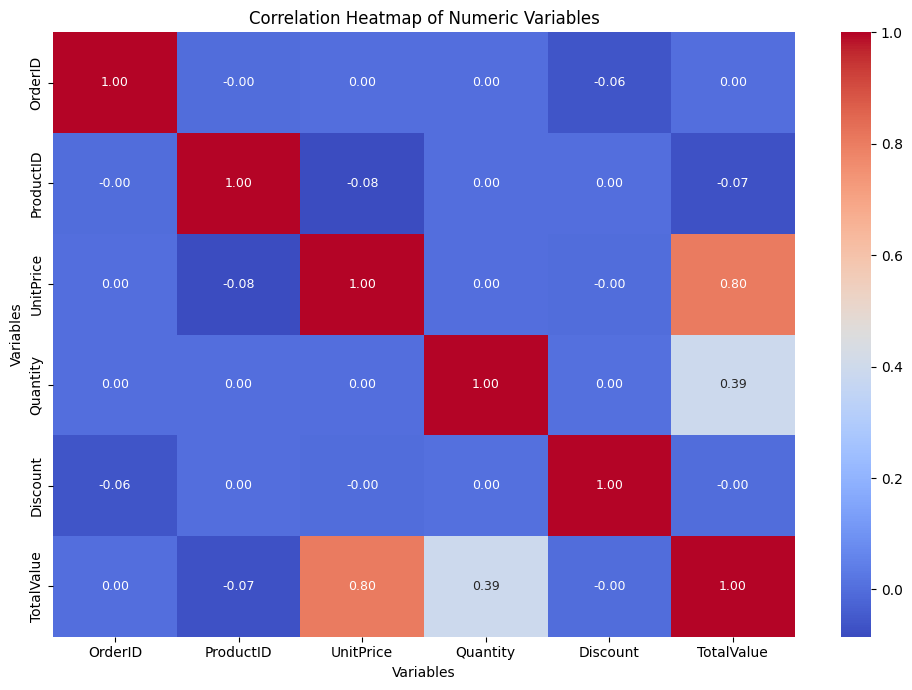

Saved: correlation_heatmap.png


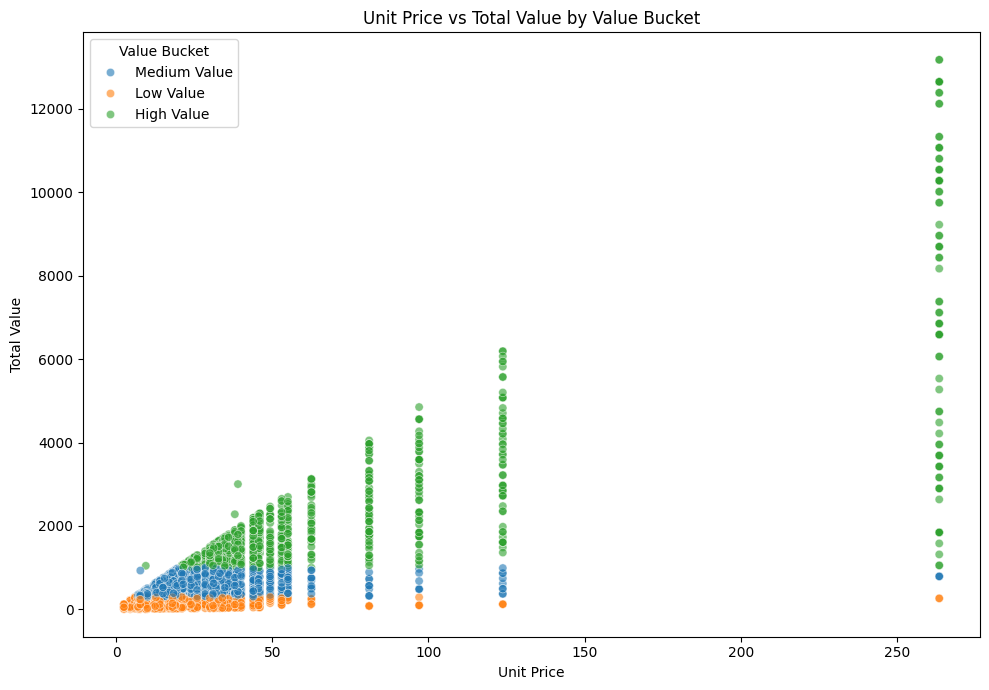

Saved: unitprice_vs_totalvalue_scatter.png


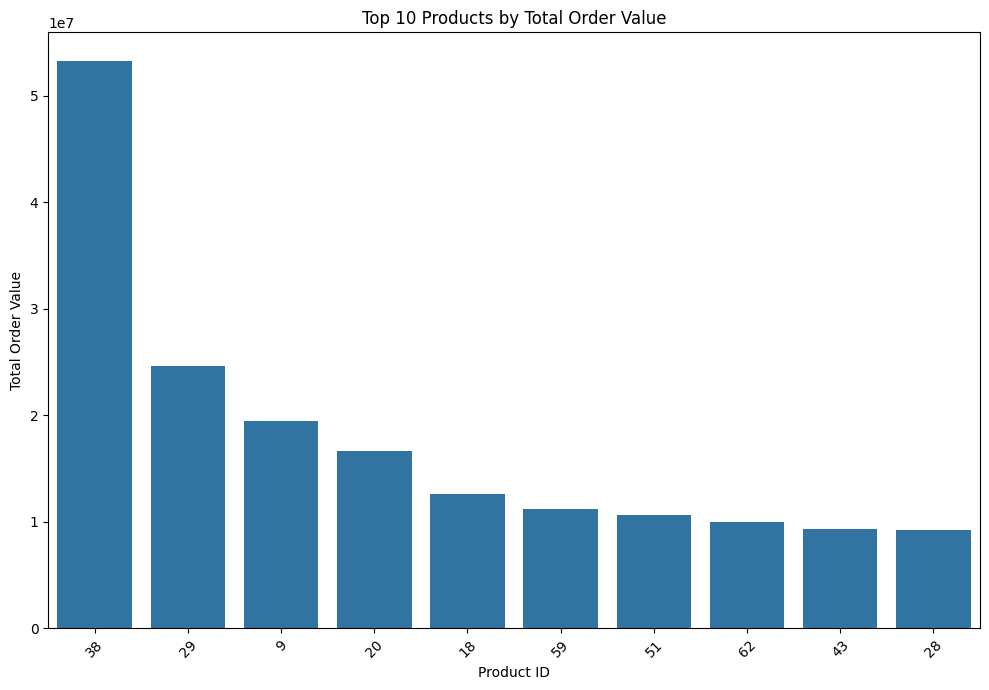

Saved: top10_products_totalvalue.png


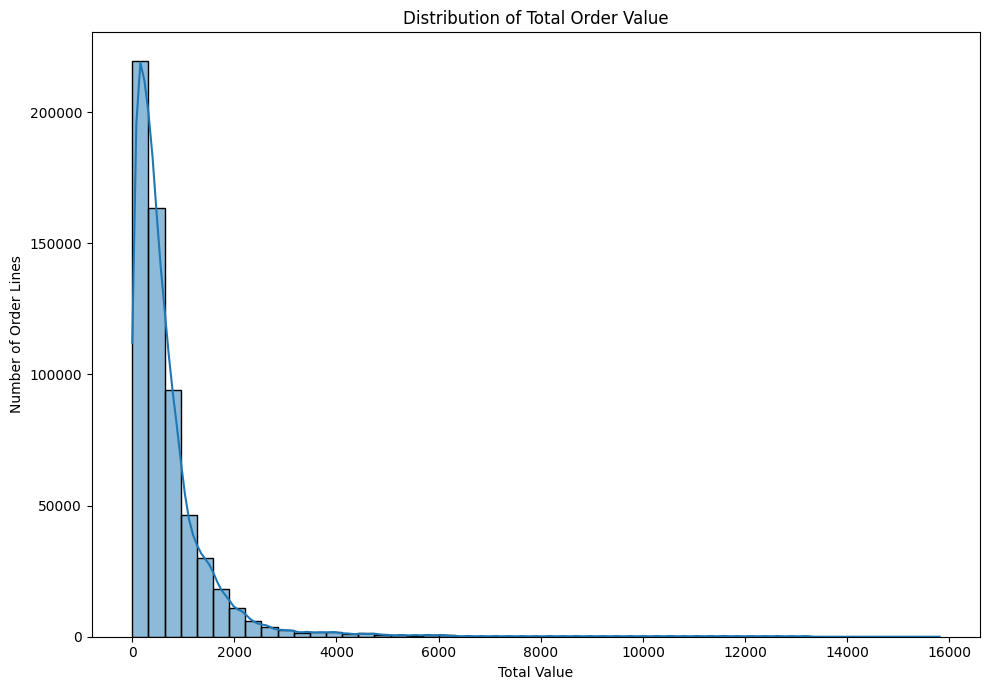

Saved: totalvalue_distribution.png

===== Visualization Files Created =====
1. correlation_heatmap.png
2. unitprice_vs_totalvalue_scatter.png
3. top10_products_totalvalue.png
4. totalvalue_distribution.png


In [10]:
# Task 10 — Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

print("===== Task 10 — Creating Visualizations =====")

# a :

numeric_columns = [
    "OrderID",
    "ProductID",
    "UnitPrice",
    "Quantity",
    "Discount",
    "TotalValue"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 9}
)

plt.title("Correlation Heatmap of Numeric Variables")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: correlation_heatmap.png")


# b :

# Use a sample so the visualization remains readable.
scatter_sample = df.sample(
    n=min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=scatter_sample,
    x="UnitPrice",
    y="TotalValue",
    hue="ValueBucket",
    alpha=0.6
)

plt.title("Unit Price vs Total Value by Value Bucket")
plt.xlabel("Unit Price")
plt.ylabel("Total Value")
plt.legend(title="Value Bucket")
plt.tight_layout()

plt.savefig("unitprice_vs_totalvalue_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: unitprice_vs_totalvalue_scatter.png")


# c :

# Calculate total TotalValue for the top 10 products.
product_sales = (
    df.groupby("ProductID")["TotalValue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=product_sales.index.astype(str),
    y=product_sales.values
)

plt.title("Top 10 Products by Total Order Value")
plt.xlabel("Product ID")
plt.ylabel("Total Order Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("top10_products_totalvalue.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: top10_products_totalvalue.png")


# d :

plt.figure(figsize=(10, 7))

sns.histplot(
    data=df,
    x="TotalValue",
    bins=50,
    kde=True
)

plt.title("Distribution of Total Order Value")
plt.xlabel("Total Value")
plt.ylabel("Number of Order Lines")
plt.tight_layout()

plt.savefig("totalvalue_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: totalvalue_distribution.png")


# Final confirmation

print("\n===== Visualization Files Created =====")
print("1. correlation_heatmap.png")
print("2. unitprice_vs_totalvalue_scatter.png")
print("3. top10_products_totalvalue.png")
print("4. totalvalue_distribution.png")